# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3464s 20us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

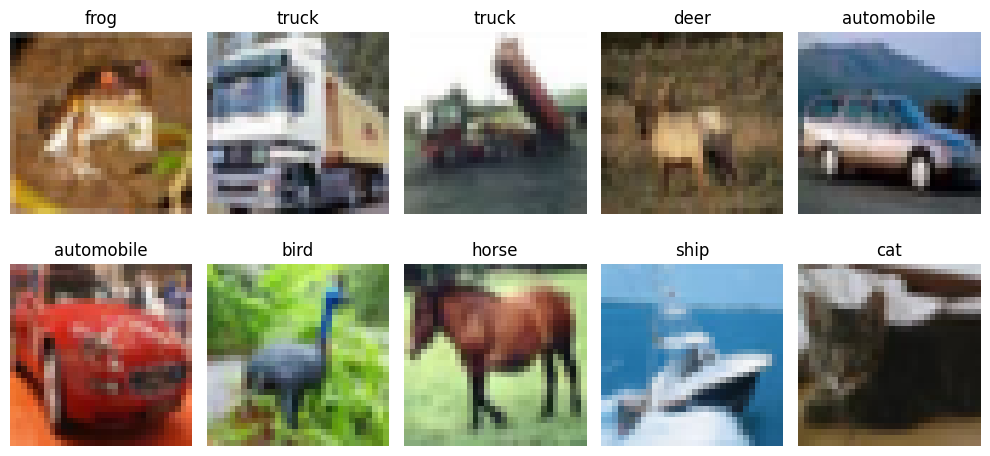

In [23]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [24]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [25]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.2716 - loss: 2.0011 - val_accuracy: 0.3090 - val_loss: 1.8775
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3202 - loss: 1.8631 - val_accuracy: 0.3632 - val_loss: 1.7806
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3424 - loss: 1.8063 - val_accuracy: 0.3842 - val_loss: 1.7488
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3570 - loss: 1.7727 - val_accuracy: 0.4034 - val_loss: 1.7050
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3625 - loss: 1.7500 - val_accuracy: 0.3902 - val_loss: 1.6996
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3728 - loss: 1.7296 - val_accuracy: 0.3984 - val_loss: 1.6999
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3771 - loss: 1.7112 - val_accuracy: 0.3964 - val_loss: 1.7004
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.3861 - loss: 1.6909 - 

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4410 - loss: 1.6152
ANN Test Accuracy: 0.4410000145435333


In [12]:
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
     layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')

])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_h2 = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3956 - loss: 1.6620 - val_accuracy: 0.4328 - val_loss: 1.6403
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.4037 - loss: 1.6522 - val_accuracy: 0.4408 - val_loss: 1.6323
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.4034 - loss: 1.6435 - val_accuracy: 0.4500 - val_loss: 1.5933
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.4091 - loss: 1.6363 - val_accuracy: 0.4424 - val_loss: 1.6025
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.4102 - loss: 1.6261 - val_accuracy: 0.4404 - val_loss: 1.5890
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.4127 - loss: 1.6292 - val_accuracy: 0.4404 - val_loss: 1.5847
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.4193 - loss: 1.6135 - val_accuracy: 0.4314 - val_loss: 1.6120
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4152 - loss: 1.6153 - 

In [13]:
ann_test_loss_v2, ann_test_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1034 - loss: 2.3450
ANN Test Accuracy: 0.4410000145435333


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.4705 - loss: 1.4772 - val_accuracy: 0.4680 - val_loss: 1.4584
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 117ms/step - accuracy: 0.6079 - loss: 1.1169 - val_accuracy: 0.5842 - val_loss: 1.2152
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.6704 - loss: 0.9473 - val_accuracy: 0.6776 - val_loss: 0.9227
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.7127 - loss: 0.8306 - val_accuracy: 0.6742 - val_loss: 0.9449
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.7472 - loss: 0.7305 - val_accuracy: 0.7182 - val_loss: 0.8233
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.7704 - loss: 0.6589 - val_accuracy: 0.6898 - val_loss: 0.9256
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 112ms/step - accuracy: 0.7914 - loss: 0.5886 - val_accuracy: 0.7134 - val_loss: 0.8576
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.8110 - loss: 0

In [15]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7192 - loss: 1.1033
CNN Test Accuracy: 0.7192000150680542


In [16]:
cnn_history_20 = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_test_loss_20, cnn_test_acc_20 = cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN 20 Epoch Accuracy:", cnn_test_acc_20)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.8850 - loss: 0.3169 - val_accuracy: 0.7168 - val_loss: 1.2035
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 115ms/step - accuracy: 0.8945 - loss: 0.2920 - val_accuracy: 0.7184 - val_loss: 1.1770
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.8988 - loss: 0.2794 - val_accuracy: 0.7162 - val_loss: 1.2049
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.9086 - loss: 0.2596 - val_accuracy: 0.7308 - val_loss: 1.1145
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 114ms/step - accuracy: 0.9133 - loss: 0.2408 - val_accuracy: 0.7234 - val_loss: 1.1774
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 113ms/step - accuracy: 0.9176 - loss: 0.2345 - val_accuracy: 0.7368 - val_loss: 1.1548
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.9219 - loss: 0.2168 - val_accuracy: 0.7154 - val_loss: 1.3034
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 113ms/step - accuracy: 0.9207 - loss: 0

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [30]:
cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_es = cnn_model_es.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_loss, cnn_es_acc = cnn_model_es.evaluate(
    x_test_norm,
    y_test
)

print("CNN + EarlyStopping Accuracy:", cnn_es_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 116ms/step - accuracy: 0.4540 - loss: 1.5240 - val_accuracy: 0.4992 - val_loss: 1.4704
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.5972 - loss: 1.1500 - val_accuracy: 0.6138 - val_loss: 1.1150
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 114ms/step - accuracy: 0.6669 - loss: 0.9658 - val_accuracy: 0.6236 - val_loss: 1.0298
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4915 - loss: 1.4881
CNN + EarlyStopping Accuracy: 0.49149999022483826


In [32]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [33]:
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_test_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 92ms/step - accuracy: 0.3634 - loss: 1.7414 - val_accuracy: 0.4820 - val_loss: 1.4375
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.4672 - loss: 1.4826 - val_accuracy: 0.5618 - val_loss: 1.2263
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5015 - loss: 1.3906 - val_accuracy: 0.5734 - val_loss: 1.1769
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.5277 - loss: 1.3266 - val_accuracy: 0.5448 - val_loss: 1.3071
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.5432 - loss: 1.2947 - val_accuracy: 0.6168 - val_loss: 1.0765
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 88ms/step - accuracy: 0.5542 - loss: 1.2547 - val_accuracy: 0.6028 - val_loss: 1.1497
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.5666 - loss: 1.2266 - val_accuracy: 0.5978 - val_loss: 1.1342
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.5709 - loss: 1.2082 - 

## 📈 Compare Learning Curves

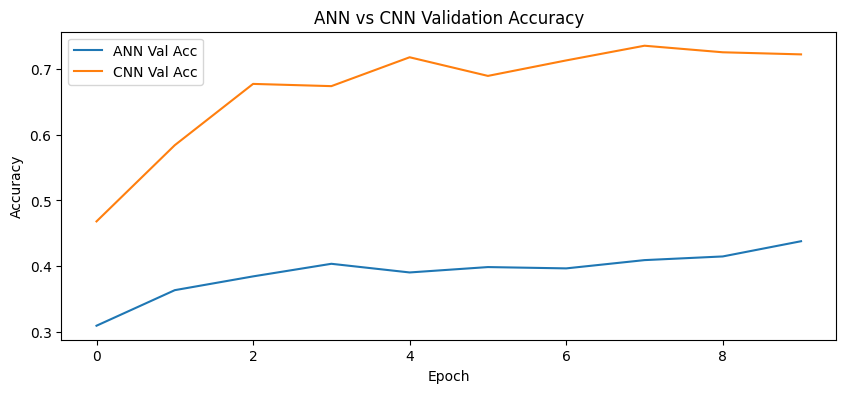

In [35]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

In [36]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "Improved ANN",
        "CNN",
        "CNN 20 Epochs",
        "CNN + EarlyStopping",
        "CNN + Augmentation"
    ],
    "Accuracy": [
        ann_test_acc,
        ann_test_acc_v2,
        cnn_test_acc,
        cnn_test_acc_20,
        cnn_es_acc,
        aug_test_acc
    ]
})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,CNN 20 Epochs,0.7199
2,CNN,0.7192
5,CNN + Augmentation,0.6195
4,CNN + EarlyStopping,0.4915
0,ANN,0.4410
1,Improved ANN,0.1034


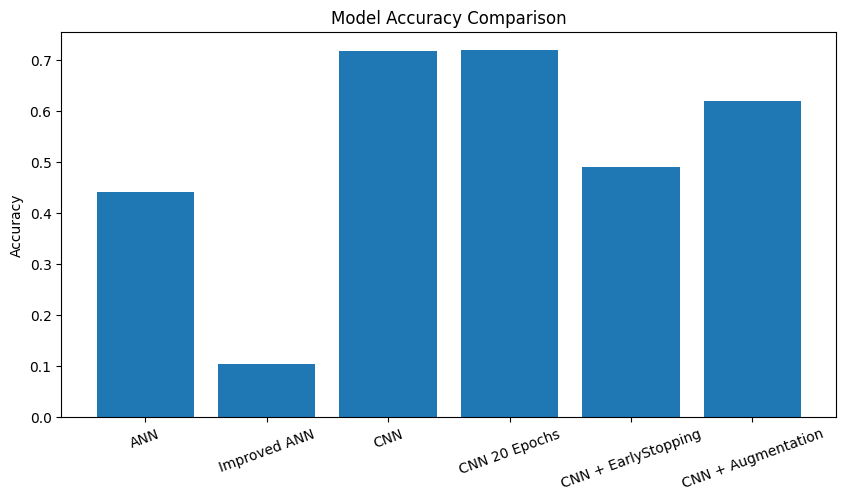

In [37]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)

plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [38]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 📊 Final Comparison Table

In [21]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4410
1,CNN,0.7192


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**